In [2]:
%load_ext autoreload
import keras
import tensorflow as tf
print(f"Keras:      {keras.__version__}")
print(f"TensorFlow: {tf.__version__}")
keras.distribution.list_devices()

I0000 00:00:1785002175.647244 2529531 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785002175.704803 2529531 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785002178.142182 2529531 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras:      3.13.2
TensorFlow: 2.21.0


I0000 00:00:1785002180.438909 2529531 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20161 MB memory:  -> device: 0, name: NVIDIA H100 NVL MIG 2g.24gb, pci bus id: 0000:c9:00.0, compute capability: 9.0a


['gpu:0']

In [3]:
%cd /scratch/saifur/zheng_encoder/scripts
%load_ext autoreload
%autoreload 2 
# Auto-reload all modules
    
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["KERAS_BACKEND"]                 = "jax"

import logging
import argparse
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import data
import model
import evaluate
import config

from data     import (sample_for_training, load_and_save_parquet, load_parquet,
                         encode_features, save_xtrain, load_xtrain, free_memory)
from model    import (build_vae, train_vae,
                       get_bottleneck, save_model)
from evaluate import (check_bottleneck_normality,
                       plot_training_history,
                       plot_compressed_distribution,
                       plot_scatter)
%cd ..

/scratch/saifur/zheng_encoder/scripts
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/scratch/saifur/zheng_encoder


In [4]:
config.PARQUET_PATH


'data/input_filtered3_with_pop_and_country_label.parquet'

In [5]:
# ── Logging setup ─────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = '%(asctime)s | %(levelname)s | %(name)s | %(message)s',
    handlers = [
        logging.StreamHandler(),
        logging.FileHandler('pipeline.log')
    ]
)
log = logging.getLogger(__name__)

In [6]:
def step_preprocess(skip_csv: bool = False):
    """Step 1: Load raw data → clean → save parquet"""
    log.info("=" * 50)
    log.info("STEP 1: Preprocessing")
    log.info("=" * 50)

    if not skip_csv:
        load_and_save_parquet(
            raw_path    = config.RAW_INPUT,
            parquet_path = config.PARQUET_PATH,
            na_rows_path = config.NA_ROWS_PATH
        )

    df = load_parquet(config.PARQUET_PATH)

    return df

In [7]:
def step_encode(df: pd.DataFrame, skip_encode: bool = False):
    """Step 2: Encode features → X_train matrix"""
    log.info("=" * 50)
    log.info("STEP 2: Feature encoding")
    log.info("=" * 50)

    if skip_encode:
        X_train = load_xtrain(config.XTRAIN_PATH)
        return X_train, df

    X_train, scaler = encode_features(df)
    save_xtrain(X_train, config.XTRAIN_PATH)

    # Free df memory — no longer needed after encoding
    free_memory(df)

    return X_train, scaler

In [8]:
def step_train(
    X_train: np.ndarray,
    X_test: np.ndarray = None,
    beta: float = None,
    epochs: int = None,
    skip_train: bool = False,
):
    """Build, train and optionally evaluate the Autoencoder."""

    log.info("=" * 50)
    log.info("STEP 3: Autoencoder Training")
    log.info("=" * 50)

    beta = beta or config.BETA
    epochs = epochs or config.EPOCHS

    vae, encoder, decoder = build_vae(
        input_dim=config.INPUT_DIM,
        latent_dim=config.LATENT_DIM,
        hidden_dim=config.HIDDEN_DIM,
        beta=beta,
    )

    if skip_train:
        from model import load_encoder

        encoder = load_encoder("vae_encoder.keras")
        return None, encoder, None, None

    vae.summary()

    history = train_vae(
        vae=vae,
        X_train=X_train,
        epochs=epochs,
        batch_size=config.BATCH_SIZE,
        validation_split=config.VALIDATION_SPLIT,
        early_stop_patience=config.EARLY_STOP_PATIENCE,
        reduce_lr_patience=config.REDUCE_LR_PATIENCE,
        reduce_lr_factor=config.REDUCE_LR_FACTOR,
        min_lr=config.MIN_LR,
    )

    save_model(vae, encoder, decoder, prefix="vae")

    plot_training_history(
        history,
        save_path="figs/training_history.png",
    )

    if X_test is not None:
        evaluate_autoencoder(
            vae,
            encoder,
            X_test,
            history,
        )

    return vae, encoder, decoder, history

In [9]:
def step_infer(encoder,
               X_test:  np.ndarray,
               df_orig:  pd.DataFrame = None):
    """Step 4: Extract bottleneck → save results"""
    log.info("=" * 50)
    log.info("STEP 4: Inference")
    log.info("=" * 50)

    z_sampled = get_bottleneck(
        encoder    = encoder,
        X          = X_test,
        batch_size = config.PREDICT_BATCH_SIZE
    )

    # Normality check
    # check_bottleneck_normality(
    #     z_mean_vals = z_mean_vals,
    #     z_sampled   = z_sampled,
    #     save_path   = 'figs/bottleneck_normality.png'
    # )

    # Attach compressed values to original dataframe
    if df_orig is not None:
        df_orig['compressed_1D'] = z_sampled.flatten()
        
        # Plots
        plot_compressed_distribution(
            df        = df_orig,
            col       = 'compressed_1D',
            group_col = 'present',
            save_path = 'figs/compressed_distribution.png'
        )
        plot_scatter(
            df        = df_orig,
            x_col     = 'expression',
            y_col     = 'compressed_1D',
            group_col = 'present',
            save_path = 'figs/scatter_expression_vs_compressed.png'
        )

        # Save output
        # log.info("Saving inferred results...")
        # df_orig.to_parquet(config.OUTPUT_PARQUET,
        #                     compression='snappy')
        # log.info(f"Saved results → {config.OUTPUT_PARQUET}")
        # # save as CSV for easy inspection
        # df_orig.to_csv("inferred_results.csv", index=False)
        # log.info(f"Saved results → inferred_results.csv")

        return df_orig

    return  z_sampled


In [9]:
df_full = step_preprocess(skip_csv=True)   

2026-07-25 00:34:32,040 | INFO | __main__ | ==================================================


2026-07-25 00:34:32,041 | INFO | __main__ | STEP 1: Preprocessing


2026-07-25 00:34:32,041 | INFO | __main__ | ==================================================


2026-07-25 00:34:32,042 | INFO | data | Loading parquet: data/input_filtered3_with_pop_and_country_label.parquet


2026-07-25 00:35:03,339 | INFO | data | Loaded 1,018,319,470 rows


In [10]:
 # Sample 1M rows for training
df_train_sample = sample_for_training(
    df          = df_full,
    n           = config.TRAIN_SAMPLE_SIZE,   # 1_000_000
    random_seed = config.RANDOM_SEED
)
# df_train_sample = df_train_sample[df_train_sample['expression'] >= -10]
log.info(f"Training sample: {len(df_train_sample):,} rows")

# Encode sample → X_train (1M rows)
log.info("Encoding training sample using NA value = %f...", config.NA_VALUE)
X_train, scaler = encode_features(df_train_sample, na_value=config.NA_VALUE)
# save_xtrain(X_train, config.XTRAIN_PATH)


2026-07-25 00:36:51,178 | INFO | data | Sampled 100,000,000 rows from 1,018,319,470 (stratified by present)


2026-07-25 00:36:51,525 | INFO | data | Sample value counts:
present
2    42113920
0    39529516
1    18356564


2026-07-25 00:36:51,527 | INFO | __main__ | Training sample: 100,000,000 rows


2026-07-25 00:36:51,527 | INFO | __main__ | Encoding training sample using NA value = -10.000000...


2026-07-25 00:36:56,794 | INFO | data | No Scaling applied to transformed columns...


2026-07-25 00:36:58,200 | INFO | data | X_train shape: (100000000, 3)


2026-07-25 00:36:58,202 | INFO | data | X_train dtype: float32


In [11]:
# ------------------------------------------------------------------
# Remaining rows in df_full become the test set
# ------------------------------------------------------------------
df_test_remaining = df_full.drop(index=df_train_sample.index).copy()
log.info(f"Remaining test set: {len(df_test_remaining):,} rows")

2026-07-25 00:39:32,734 | INFO | __main__ | Remaining test set: 918,319,470 rows


In [12]:
X_test, _ = encode_features(
    df_test_remaining,
    na_value=config.NA_VALUE,
    scaler=scaler,   # reuse training scaler if your function supports it
)

2026-07-25 00:43:02,570 | INFO | data | No Scaling applied to transformed columns...


2026-07-25 00:44:10,783 | INFO | data | X_train shape: (918319470, 3)


2026-07-25 00:44:10,785 | INFO | data | X_train dtype: float32


In [13]:
df_test_sample = df_test_remaining.sample(n=int(config.TRAIN_SAMPLE_SIZE), random_state=config.RANDOM_SEED)

In [14]:
X_test_100M, _ = encode_features(
    df_test_sample,
    na_value=config.NA_VALUE,
    scaler=scaler,   # reuse training scaler if your function supports it
)

2026-07-25 00:45:49,001 | INFO | data | No Scaling applied to transformed columns...


2026-07-25 00:45:50,572 | INFO | data | X_train shape: (100000000, 3)


2026-07-25 00:45:50,574 | INFO | data | X_train dtype: float32


In [15]:
df_train_sample.to_parquet("data/df_train_sample.parquet")
df_test_remaining.to_parquet("data/df_test_remaining.parquet")
df_test_sample.to_parquet("data/df_test_sample_100M.parquet")

In [29]:
del df_train_sample
del df_test_remaining
del df_test_sample

In [10]:
df_test_sample = pd.read_parquet("data/df_test_sample_100M.parquet")

In [22]:
df_train_sample = pd.read_parquet("data/df_train_sample.parquet")

In [18]:
df_test_sample

,gene,sample,present,expression,pop_label,sex,country_label
108998705,>120187502>120187504:3:1:7:SNP,HG02668,0,0.00,AFR,male,GWD
158692532,>128251780:190:192:359:SV_del,NA19240,1,53.80,AFR,female,YRI
768899938,>54700415:3:5:352:SV_del,HG04199,2,62.25,SAS,male,STU
848178236,>69406459>69406460:0:1:179:SNP,HG03270,1,93.70,AFR,female,ESN
82391353,>116698314>116698316:7:1:157:SNP,HG02841,2,96.15,AFR,female,GWD
...,...,...,...,...,...,...,...
637275740,>22696823:69:71:54:SV_ins,HG03804,0,0.00,SAS,female,BEB
808382003,>60707525>60707526:18:1:402:SNP,HG02602,2,84.25,SAS,male,PJL
82665001,>116731947>116731949:0:1:434:SNP,NA19909,2,86.70,AFR,female,ASW
166433648,>129211625>129211628:0:1:392:SNP,NA19043,2,93.30,AFR,male,LWK


/tmp/ipykernel_2096334/3363357832.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


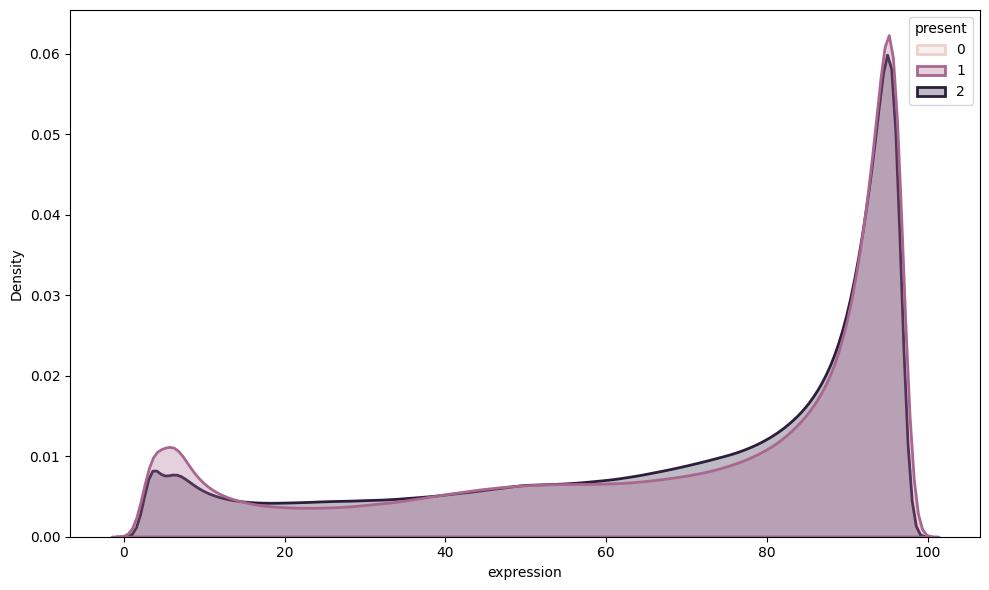

In [16]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_train_sample,
    x="expression",
    hue="present",
    hue_order=[0,1,2],
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2
)

plt.tight_layout()
plt.show()

2026-07-25 00:52:49,022 | INFO | __main__ | Test sample: 100,000,000 rows


/tmp/ipykernel_2096334/3155468691.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


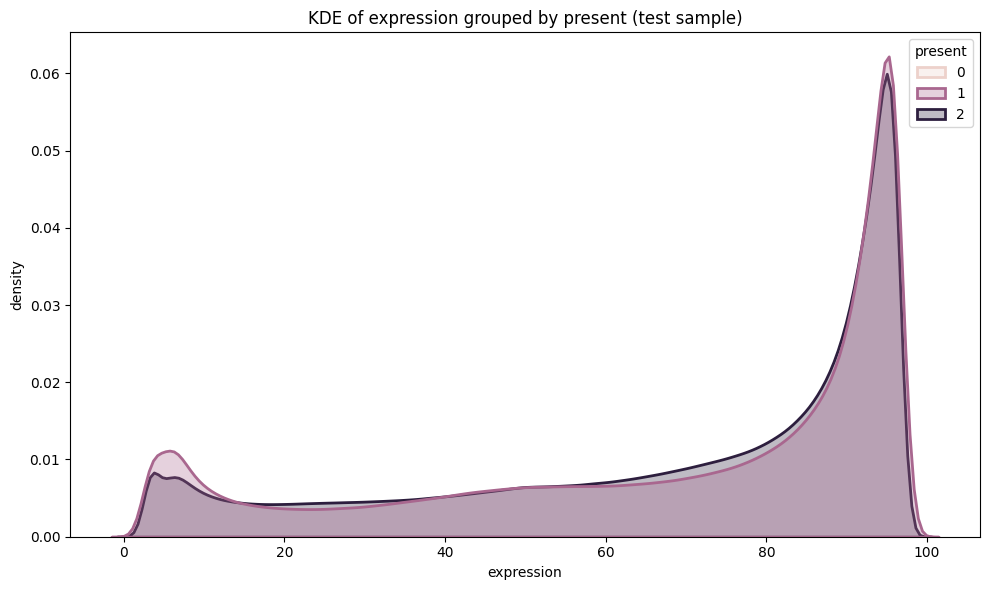

In [17]:
# Sample up to 100M rows from the test set


log.info(f"Test sample: {len(df_test_sample):,} rows")

# KDE plot of expression grouped by present
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_test_sample,
    x="expression",
    hue="present",
    hue_order=sorted(df_test_sample["present"].dropna().unique()),
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2,
)

plt.title("KDE of expression grouped by present (test sample)")
plt.xlabel("expression")
plt.ylabel("density")
plt.tight_layout()
plt.show()

In [19]:
np.savez_compressed("data/X_train_all.npz", X_train=X_train)

In [21]:
np.savez_compressed("data/X_test_all.npz", X_test=X_test)

In [22]:
np.savez_compressed("data/X_test_100M.npz", X_test_100M=X_test_100M)

## Model training

In [11]:
X_train = np.load("data/X_train_all.npz")['X_train']
X_test_100M = np.load("data/X_test_100M.npz")['X_test_100M']
# X_train = np.load("data/X_train_compressed.npz")['train_data']

In [13]:
model = tf.keras.models.load_model("data/autoencoder_full.keras")
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

encoder = model.get_layer("Encoder")
decoder = model.get_layer("Decoder")

0 encoder_input <class 'keras.src.layers.core.input_layer.InputLayer'>
1 Encoder <class 'keras.src.models.functional.Functional'>
2 Decoder <class 'keras.src.models.functional.Functional'>


In [14]:
df_result = step_infer(
        encoder  = encoder,
        X_test  = X_train, 
    )

2026-07-25 12:56:44,206 | INFO | __main__ | ==================================================


2026-07-25 12:56:44,207 | INFO | __main__ | STEP 4: Inference


2026-07-25 12:56:44,208 | INFO | __main__ | ==================================================


2026-07-25 12:56:44,208 | INFO | model | Extracting bottleneck for 100,000,000 samples...


I0000 00:00:1785002206.098230 2531515 service.cc:153] XLA service 0x7f083c02cb00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785002206.098249 2531515 service.cc:161]   StreamExecutor [0]: NVIDIA H100 NVL MIG 2g.24gb, Compute Capability 9.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1785002206.102333 2531515 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785002206.125396 2531515 cuda_dnn.cc:461] Loaded cuDNN version 92000


...

2026-07-25 12:56:56,566 | INFO | model | Bottleneck shape: (100000000, 1)


2026-07-25 12:56:56,607 | INFO | model |   mean = -26.1376


2026-07-25 12:56:56,805 | INFO | model |   std  = 36.5906


2026-07-25 12:56:56,827 | INFO | model |   min  = -87.3962


2026-07-25 12:56:56,847 | INFO | model |   max  = 4.1192


In [18]:
X_pred = model.predict(X_train, batch_size=config.PREDICT_BATCH_SIZE)

    1/12208 ━━━━━━━━━━━━━━━━━━━━ 2:43:14 802ms/step

  102/12208 ━━━━━━━━━━━━━━━━━━━━ 6s 498us/step     

  216/12208 ━━━━━━━━━━━━━━━━━━━━ 5s 468us/step

  328/12208 ━━━━━━━━━━━━━━━━━━━━ 5s 462us/step

  440/12208 ━━━━━━━━━━━━━━━━━━━━ 5s 458us/step

...

11986/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step

12085/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step

12173/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step

12208/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step

12208/12208 ━━━━━━━━━━━━━━━━━━━━ 8s 595us/step


In [19]:
X_test_pred = model.predict(X_test_100M, batch_size=config.PREDICT_BATCH_SIZE)

    1/12208 ━━━━━━━━━━━━━━━━━━━━ 47:56 236ms/step

  107/12208 ━━━━━━━━━━━━━━━━━━━━ 5s 473us/step   

  221/12208 ━━━━━━━━━━━━━━━━━━━━ 5s 455us/step

  336/12208 ━━━━━━━━━━━━━━━━━━━━ 5s 449us/step

  444/12208 ━━━━━━━━━━━━━━━━━━━━ 5s 453us/step

...

11860/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step

11947/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step

12037/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step

12124/12208 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step

12208/12208 ━━━━━━━━━━━━━━━━━━━━ 6s 486us/step


In [20]:
rmse_train = np.sqrt(np.mean((X_pred - X_train) ** 2, axis=1))
rmse_test = np.sqrt(np.mean((X_test_pred  - X_test_100M) ** 2, axis=1))

In [23]:
df_train_sample['rmse'] = rmse_train
df_test_sample['rmse'] = rmse_test

In [24]:
df_train_sample['split'] = 'train'
df_test_sample['split'] = 'test'
df_combined = pd.concat([df_train_sample, df_test_sample], ignore_index=True)

In [25]:
df_combined

,gene,sample,present,expression,pop_label,sex,country_label,rmse,split
0,>125650140>125650141:86:1:240:SNP,HG00544,1,43.20,EAS,female,CHS,0.068085,train
1,>58775557>58775559:0:1:432:SNP,HG03579,2,66.40,AFR,male,MSL,0.022225,train
2,>9995921>9995922:208:1:432:SNP,HG00280,2,28.10,EUR,male,FIN,0.012061,train
3,>110470417>110470419:53:1:12:SNP,HG03369,0,0.00,AFR,female,ESN,0.052276,train
4,>186395732>186395734:0:1:428:SNP,HG02976,2,78.00,AFR,female,ESN,0.015162,train
...,...,...,...,...,...,...,...,...,...
199999995,>22696823:69:71:54:SV_ins,HG03804,0,0.00,SAS,female,BEB,0.052276,test
199999996,>60707525>60707526:18:1:402:SNP,HG02602,2,84.25,SAS,male,PJL,0.029028,test
199999997,>116731947>116731949:0:1:434:SNP,NA19909,2,86.70,AFR,female,ASW,0.027877,test
199999998,>129211625>129211628:0:1:392:SNP,NA19043,2,93.30,AFR,male,LWK,0.029328,test


## Validation

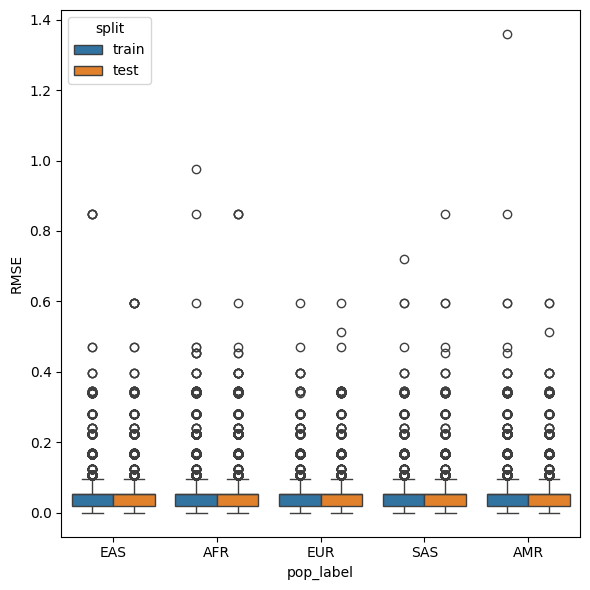

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Box plot
plt.figure(figsize=(6, 6))
sns.boxplot(data=df_combined, y="rmse", x = "pop_label", hue = "split")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig("rmse_boxplot.pdf", bbox_inches="tight")
plt.show()

In [27]:
X_train

array([[-10. ,  43.2, -10. ],
       [-10. , -10. ,  66.4],
       [-10. , -10. ,  28.1],
       ...,
       [  0. , -10. , -10. ],
       [-10. ,  91. , -10. ],
       [-10. ,  86.7, -10. ]], shape=(100000000, 3), dtype=float32)

In [26]:
X_pred

array([[-1.0014170e+01,  4.3083389e+01, -1.0010373e+01],
       [-1.0002043e+01, -1.0008183e+01,  6.6362442e+01],
       [-9.9999733e+00, -1.0000214e+01,  2.8079111e+01],
       ...,
       [-2.9775620e-02, -1.0083786e+01, -1.0017080e+01],
       [-1.0007080e+01,  9.0918037e+01, -1.0005125e+01],
       [-1.0007277e+01,  8.6601501e+01, -1.0005280e+01]],
      shape=(100000000, 3), dtype=float32)

In [32]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    classification_report,
)
from sklearn.preprocessing import label_binarize

# Row-wise predicted class from each array
y_true = np.argmax(X_test_100M, axis=1)
y_pred = np.argmax(X_test_pred, axis=1)

classes = np.array(sorted(np.unique(np.concatenate([y_true, y_pred]))))
n_classes = len(classes)

# Class-wise precision / recall / F1
prec, rec, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=classes,
    zero_division=0
)

results = pd.DataFrame({
    "class": classes,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": support,
})

print(results)

# Overall F1 scores
print("macro F1   :", f1_score(y_true, y_pred, average="macro"))
print("weighted F1:", f1_score(y_true, y_pred, average="weighted"))
print("micro F1   :", f1_score(y_true, y_pred, average="micro"))

# AUROC / AUPRC need score matrices, not argmax labels
# Use the full arrays as scores and binarize y_true
y_true_bin = label_binarize(y_true, classes=classes)

# If your classes are 0..K-1 and one class is missing, this still works
auroc_per_class = roc_auc_score(y_true_bin, X_pred[:, classes], average=None)
auprc_per_class = average_precision_score(y_true_bin, X_pred[:, classes], average=None)

results["auroc"] = auroc_per_class
results["auprc"] = auprc_per_class

print("\nClass-wise metrics:")
print(results)

print("\nMacro AUROC:", roc_auc_score(y_true_bin, X_pred[:, classes], average="macro"))
print("Weighted AUROC:", roc_auc_score(y_true_bin, X_pred[:, classes], average="weighted"))
print("Macro AUPRC:", average_precision_score(y_true_bin, X_pred[:, classes], average="macro"))
print("Weighted AUPRC:", average_precision_score(y_true_bin, X_pred[:, classes], average="weighted"))

   class  precision  recall   f1   support
0      0        1.0     1.0  1.0  39542655
1      1        1.0     1.0  1.0  18348182
2      2        1.0     1.0  1.0  42109163


macro F1   : 1.0


weighted F1: 1.0


micro F1   : 1.0



Class-wise metrics:
   class  precision  recall   f1   support     auroc     auprc
0      0        1.0     1.0  1.0  39542655  0.500122  0.395499
1      1        1.0     1.0  1.0  18348182  0.499993  0.183489
2      2        1.0     1.0  1.0  42109163  0.500089  0.421153



Macro AUROC: 0.5000678360926517


Weighted AUROC: 0.5000843083567678


Macro AUPRC: 0.33338033615563684


Weighted AUPRC: 0.3674016387598719


In [31]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

# row-wise max for each sample
y_true = np.max(X_test_100M, axis=1)
y_pred = np.max(X_test_pred, axis=1)

# metrics
pearson_r, pearson_p = pearsonr(y_true, y_pred)
spearman_r, spearman_p = spearmanr(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Pearson r : {pearson_r:.6f} (p={pearson_p:.3e})")
print(f"Spearman r: {spearman_r:.6f} (p={spearman_p:.3e})")
print(f"R2        : {r2:.6f}")

Pearson r : 0.995550 (p=0.000e+00)
Spearman r: 0.999999 (p=0.000e+00)
R2        : 0.999998
